# 03 - Feature Engineering and Feature Selection

**Objective**: Identify the most discriminative features for CVD prediction.

Methods:
- Pearson and Spearman correlation
- Gini importance (Random Forest)
- Chi-square test for categorical variables
- Derived features
- PCA (optional)

In [167]:
# Imports
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier

from scipy.stats import chi2_contingency
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler as SklearnScaler

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

TARGET_COL = 'HeartDiseaseorAttack'
EDA_SAMPLE_ROWS = 200000
RF_SAMPLE_FRACTION = 0.3
PCA_MAX_ROWS = 50000

spark = (
    SparkSession.builder
    .appName('BRFSS_FeatureEngineering')
    .master('local[*]')
    .config('spark.driver.memory', '8g')
    .getOrCreate()
)

print('Imports and Spark ready')

Imports and Spark ready


26/05/28 23:06:02 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [168]:
# Load cleaned data from Phase 1
df_spark = spark.read.parquet('/kaggle/working/brfss_cleaned.parquet').cache()
row_count = df_spark.count()
col_count = len(df_spark.columns)
print(f'Data loaded: {row_count:,} rows x {col_count} columns')

if TARGET_COL not in df_spark.columns:
    raise ValueError(f'Missing target column: {TARGET_COL}')

# Sample for pandas-based EDA to avoid memory issues
fraction = min(1.0, EDA_SAMPLE_ROWS / float(row_count))
df_sample = df_spark.sample(False, fraction, seed=42)
df_pd = df_sample.toPandas()
print(f'Pandas sample: {df_pd.shape}')
print(f'Columns: {list(df_pd.columns)}')

26/05/28 23:06:02 WARN CacheManager: Asked to cache already cached data.


Data loaded: 1,760,241 rows x 14 columns
Pandas sample: (199888, 14)
Columns: ['HeartDiseaseorAttack', 'BMI', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'HvyAlcoholConsump']


## 1. Correlation analysis

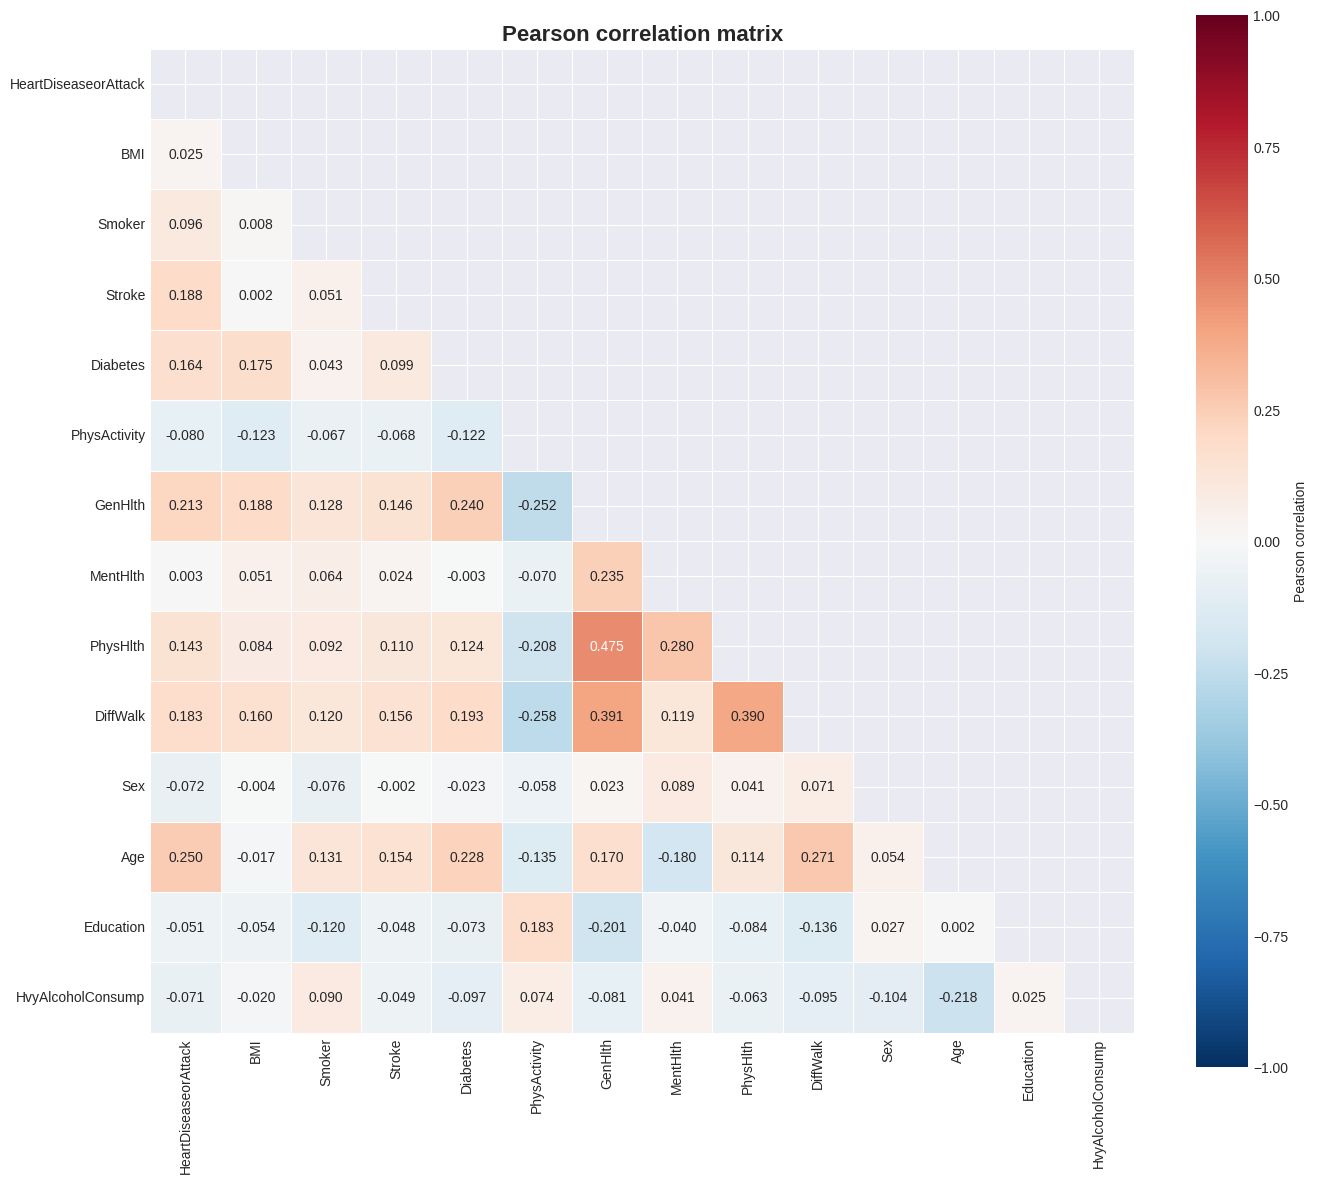

In [169]:
# Pearson correlation
corr_pearson = df_pd.corr(method='pearson')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Pearson correlation matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/corr_pearson.png', dpi=150, bbox_inches='tight')
plt.show()

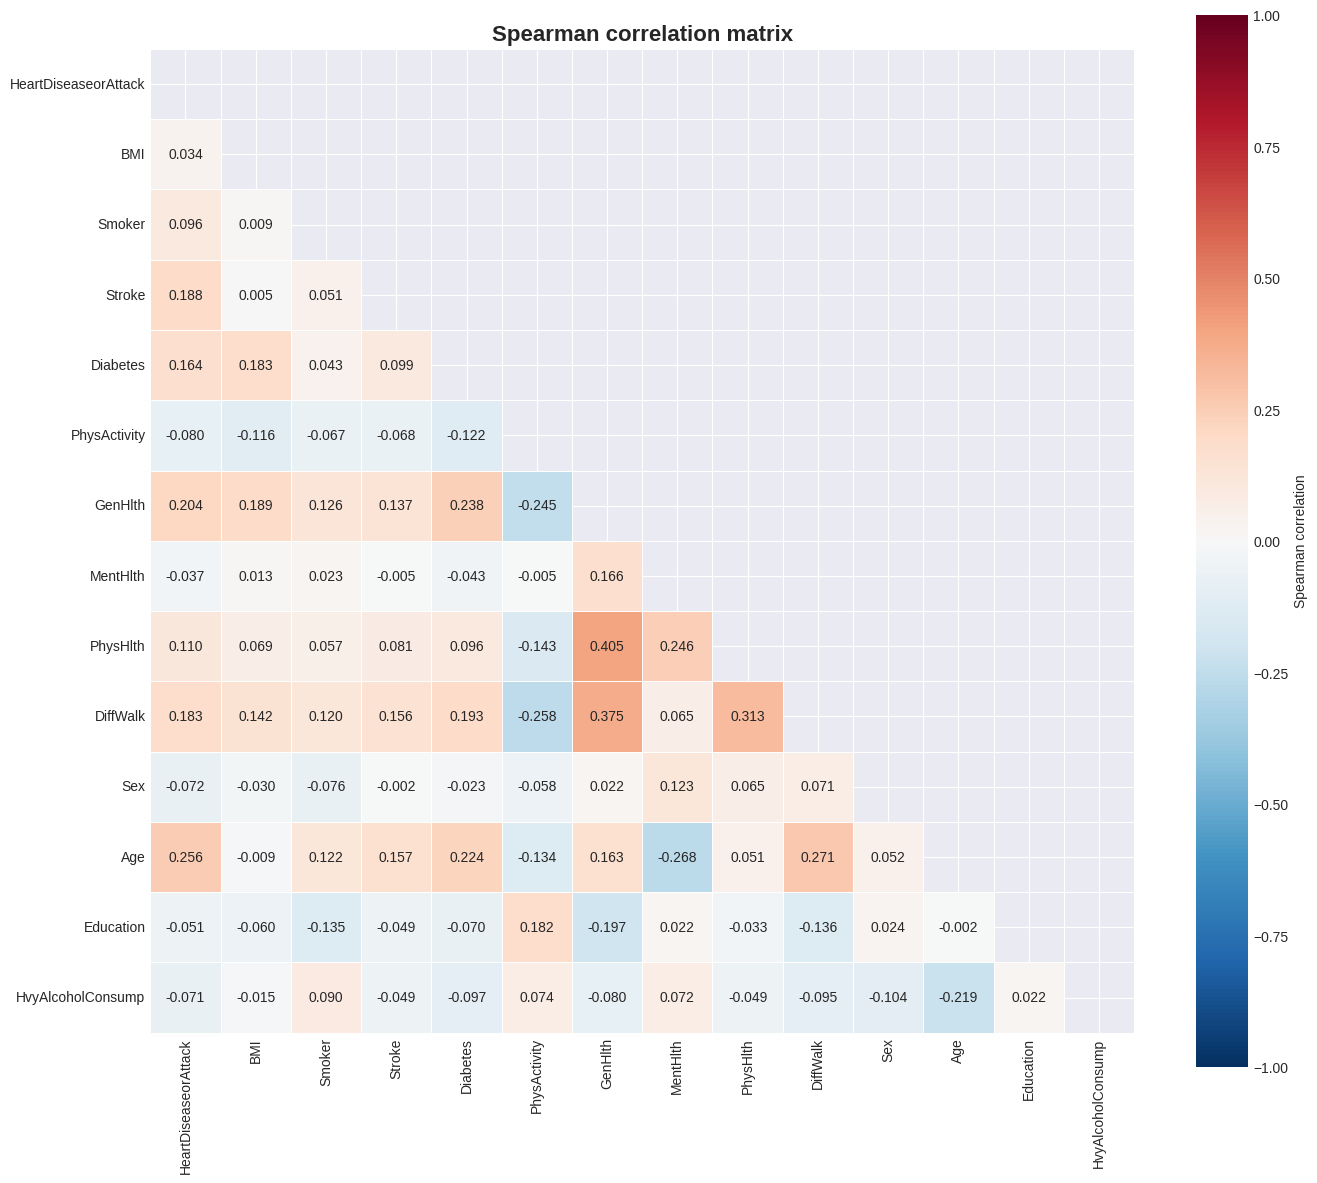

In [170]:
# Spearman correlation (better for ordinal features)
corr_spearman = df_pd.corr(method='spearman')

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'label': 'Spearman correlation'})
plt.title('Spearman correlation matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/corr_spearman.png', dpi=150, bbox_inches='tight')
plt.show()

Correlation with target:
                    Pearson  Spearman
Age                0.250119  0.256121
GenHlth            0.212742  0.203745
Stroke             0.188268  0.188268
DiffWalk           0.182677  0.182677
Diabetes           0.164354  0.164354
PhysHlth           0.142649  0.110367
Smoker             0.096323  0.096323
BMI                0.024811  0.034383
MentHlth           0.002991 -0.036929
Education         -0.050564 -0.050890
HvyAlcoholConsump -0.071257 -0.071257
Sex               -0.072215 -0.072215
PhysActivity      -0.080108 -0.080108


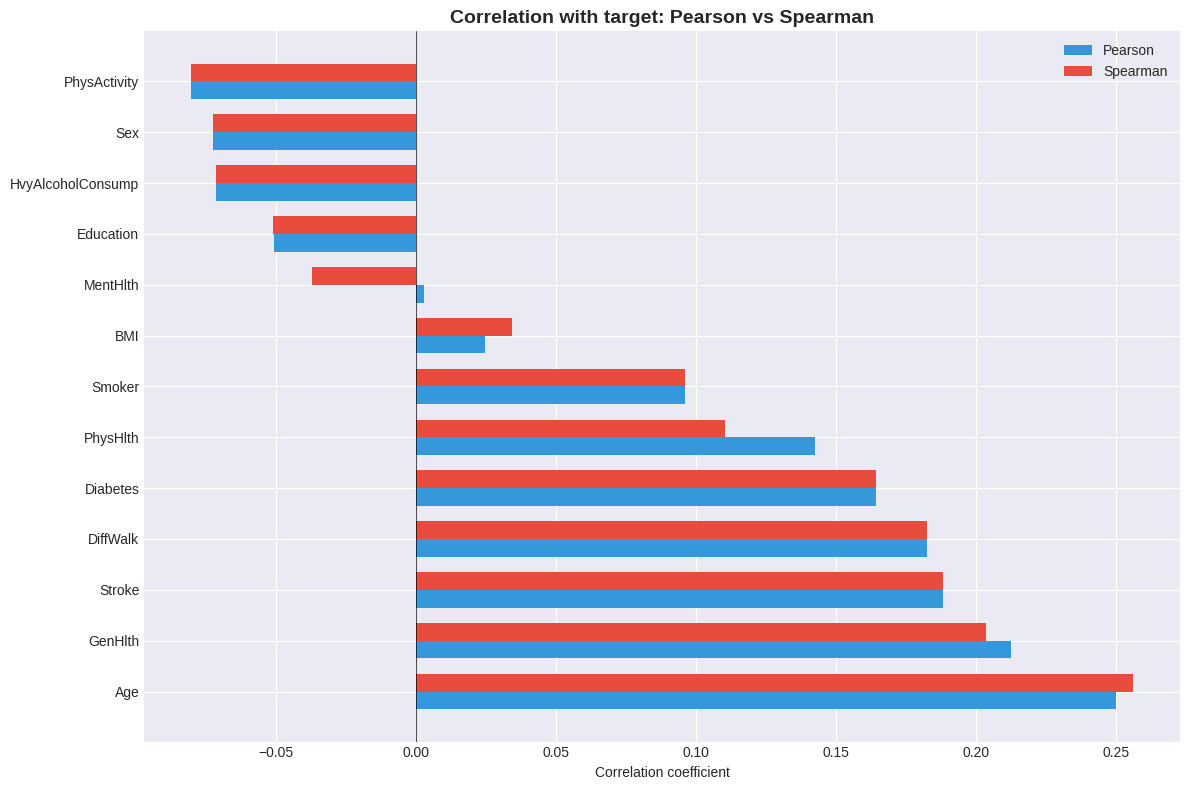

In [171]:
# Correlation with target (Pearson vs Spearman)
target_pearson = corr_pearson[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
target_spearman = corr_spearman[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

corr_comparison = pd.DataFrame({
    'Pearson': target_pearson,
    'Spearman': target_spearman
}).sort_values('Pearson', ascending=False)

print('Correlation with target:')
print(corr_comparison.to_string())

fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(corr_comparison))
width = 0.35
ax.barh(x - width / 2, corr_comparison['Pearson'], width, label='Pearson', color='#3498db')
ax.barh(x + width / 2, corr_comparison['Spearman'], width, label='Spearman', color='#e74c3c')
ax.set_yticks(x)
ax.set_yticklabels(corr_comparison.index)
ax.set_xlabel('Correlation coefficient')
ax.set_title('Correlation with target: Pearson vs Spearman', fontsize=14, fontweight='bold')
ax.legend()
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('/kaggle/working/corr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Gini importance (Random Forest)

In [172]:
# Prepare data for Spark ML
feature_cols = [c for c in df_spark.columns if c != TARGET_COL]
if not feature_cols:
    raise ValueError('No feature columns available for Random Forest.')

df_clean = df_spark.select(feature_cols + [TARGET_COL]).na.drop()
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')
df_ml = assembler.transform(df_clean).select('features', F.col(TARGET_COL).cast('double').alias('label'))

# Sample for faster training on large datasets
if row_count > 500000:
    rf_df = df_ml.sample(False, RF_SAMPLE_FRACTION, seed=42)
else:
    rf_df = df_ml

rf = RandomForestClassifier(
    labelCol='label',
    featuresCol='features',
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf.fit(rf_df)

importances = rf_model.featureImportances.toArray()
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Gini': importances
}).sort_values('Importance_Gini', ascending=False)

print('Gini importance (Random Forest):')
print(feature_importance_df.to_string(index=False))

26/05/28 23:06:49 WARN DAGScheduler: Broadcasting large task binary with size 1873.3 KiB
26/05/28 23:06:58 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/05/28 23:07:14 WARN DAGScheduler: Broadcasting large task binary with size 1115.5 KiB
26/05/28 23:07:15 WARN DAGScheduler: Broadcasting large task binary with size 7.0 MiB
26/05/28 23:07:36 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/28 23:07:38 WARN DAGScheduler: Broadcasting large task binary with size 13.4 MiB
26/05/28 23:07:57 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB


Gini importance (Random Forest):
          Feature  Importance_Gini
              Age         0.340621
          GenHlth         0.203286
           Stroke         0.161297
         Diabetes         0.068093
         DiffWalk         0.067008
              Sex         0.057302
         PhysHlth         0.032561
           Smoker         0.018752
              BMI         0.018632
         MentHlth         0.014191
        Education         0.010213
HvyAlcoholConsump         0.004541
     PhysActivity         0.003504


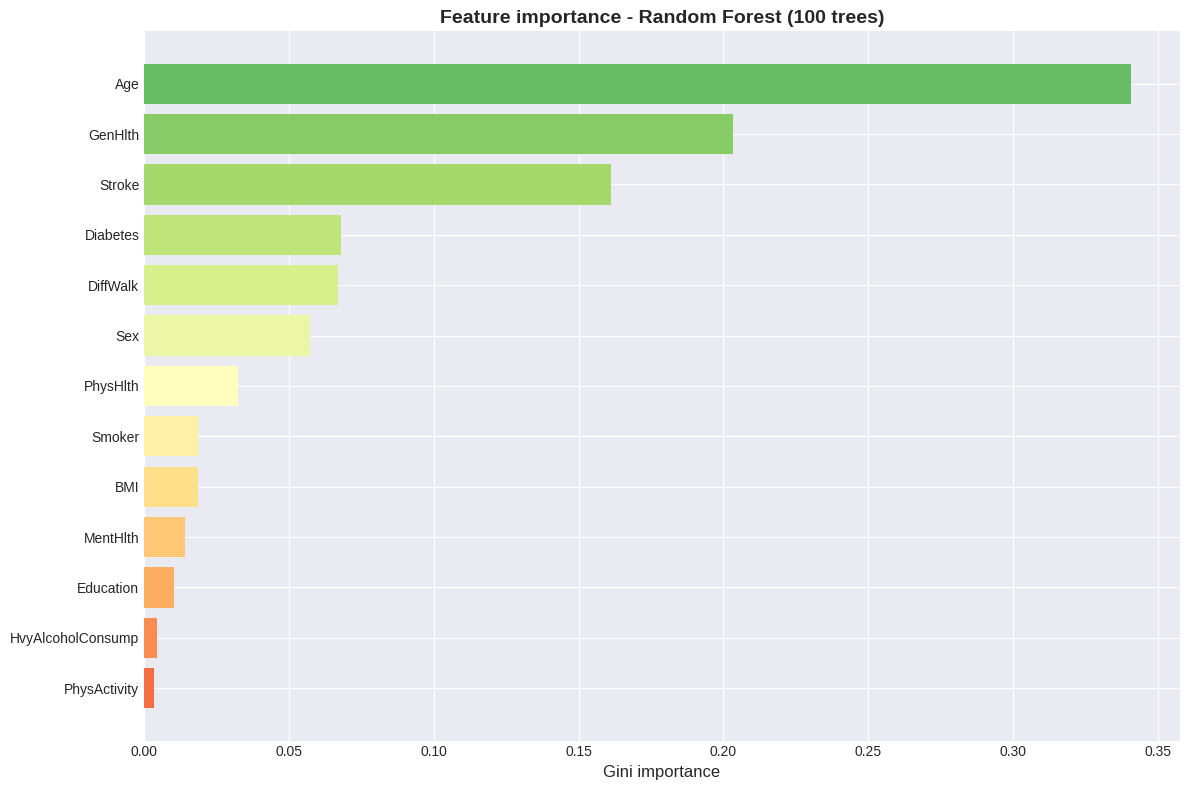

In [173]:
# Plot Gini importance
plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(feature_importance_df)))
plt.barh(range(len(feature_importance_df)), feature_importance_df['Importance_Gini'].values, color=colors)
plt.yticks(range(len(feature_importance_df)), feature_importance_df['Feature'].values)
plt.xlabel('Gini importance', fontsize=12)
plt.title('Feature importance - Random Forest (100 trees)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance_gini.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Chi-square test for categorical variables

In [174]:
# Chi-square test vs target for categorical features
categorical_candidates = [
    'HighBP', 'HighChol', 'Smoker', 'Stroke', 'Diabetes',
    'PhysActivity', 'DiffWalk', 'Sex', 'GenHlth', 'Age',
    'Education', 'Income', 'HvyAlcoholConsump', 'NoDocbcCost'
]
categorical_cols = [c for c in categorical_candidates if c in df_pd.columns]

if not categorical_cols:
    print('No categorical columns available for chi-square test.')
    chi2_df = pd.DataFrame(columns=['Variable', 'Chi2', 'p_value', 'Cramers_V', 'Significant'])
else:
    chi2_results = []
    for col in categorical_cols:
        contingency = pd.crosstab(df_pd[col], df_pd[TARGET_COL])
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        n = contingency.sum().sum()
        min_dim = min(contingency.shape) - 1
        cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
        chi2_results.append({
            'Variable': col,
            'Chi2': chi2,
            'p_value': p_value,
            'Cramers_V': cramers_v,
            'Significant': 'yes' if p_value < 0.05 else 'no'
        })
    chi2_df = pd.DataFrame(chi2_results).sort_values('Cramers_V', ascending=False)
    print('Chi-square test results:')
    print(chi2_df.to_string(index=False))

Chi-square test results:
         Variable         Chi2       p_value  Cramers_V Significant
              Age 13570.710269  0.000000e+00   0.260560         yes
          GenHlth 10108.056394  0.000000e+00   0.224875         yes
           Stroke  7082.174166  0.000000e+00   0.188230         yes
         DiffWalk  6668.870731  0.000000e+00   0.182656         yes
         Diabetes  5397.967683  0.000000e+00   0.164332         yes
           Smoker  1853.950756  0.000000e+00   0.096307         yes
     PhysActivity  1282.155642 8.532406e-281   0.080090         yes
              Sex  1041.937728 1.376260e-228   0.072198         yes
HvyAlcoholConsump  1014.264456 1.424653e-222   0.071233         yes
        Education   560.485265 6.952783e-119   0.052953         yes


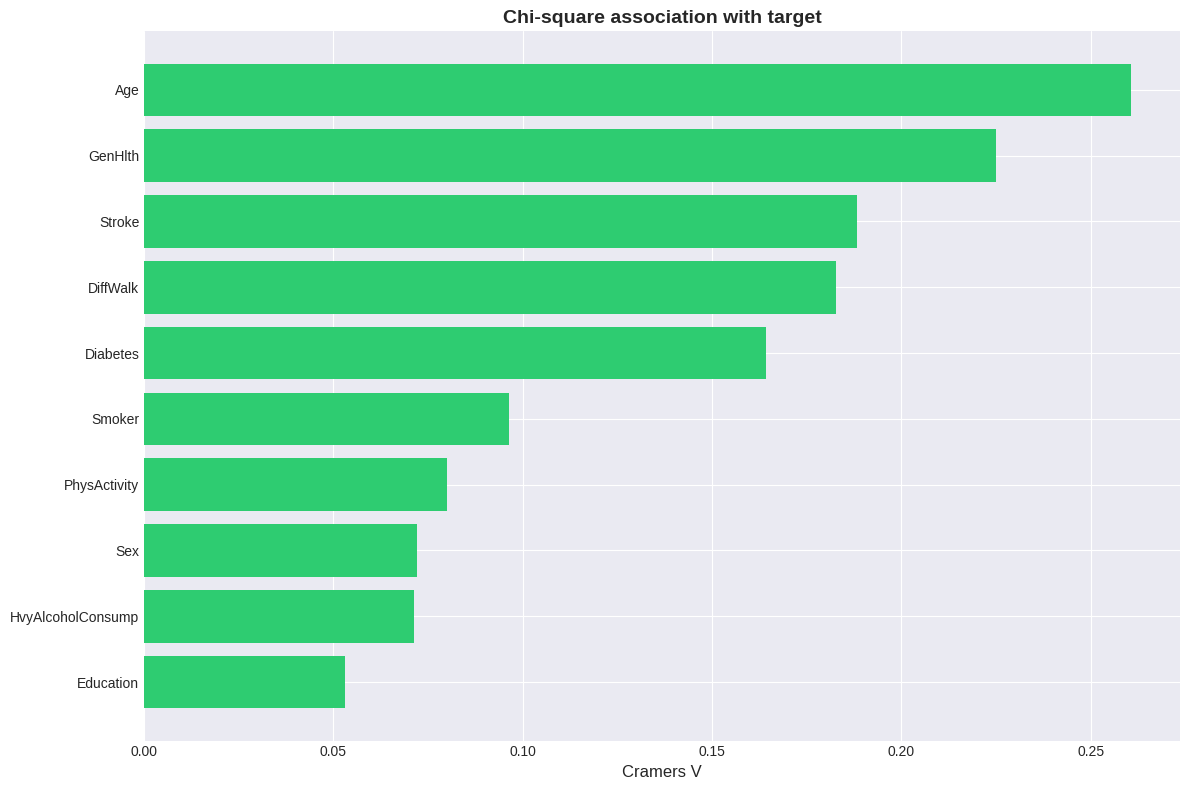

In [175]:
# Plot Cramers V
if chi2_df.empty:
    print('Skip plot: chi2_df is empty.')
else:
    plt.figure(figsize=(12, 8))
    colors = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in chi2_df['p_value']]
    plt.barh(range(len(chi2_df)), chi2_df['Cramers_V'].values, color=colors)
    plt.yticks(range(len(chi2_df)), chi2_df['Variable'].values)
    plt.xlabel('Cramers V', fontsize=12)
    plt.title('Chi-square association with target', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('/kaggle/working/chi2_cramers_v.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Variables derivees

**RiskScore** : somme des facteurs de risque binaires disponibles.

PRD prévu : `HighBP + HighChol + Smoker + Diabetes`
Dataset réel : `HighBP` et `HighChol` sont absents du fichier `_ml` pooled.
→ Formule adaptée : `Smoker + Diabetes + Stroke + DiffWalk + HvyAlcoholConsump` (5 facteurs binaires 0/1 après Phase 1 fix).

**HealthIndex** : indice composite de santé subjective.
Formule : `GenHlth + MentHlth/6 + PhysHlth/6`
(GenHlth sur 5 pts, les deux autres ramenés à la même échelle)

In [176]:
# Derived features: RiskScore and HealthIndex
risk_components = [c for c in ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'Stroke', 'DiffWalk', 'HvyAlcoholConsump'] if c in df_spark.columns]
if risk_components:
    risk_expr = None
    for c in risk_components:
        risk_expr = F.col(c) if risk_expr is None else (risk_expr + F.col(c))
    df_spark = df_spark.withColumn('RiskScore', risk_expr)
    print(f'RiskScore created from: {risk_components}')
else:
    print('RiskScore skipped: no risk components available.')

health_required = ['GenHlth', 'MentHlth', 'PhysHlth']
if all(c in df_spark.columns for c in health_required):
    df_spark = df_spark.withColumn(
        'HealthIndex',
        F.col('GenHlth') + (F.col('MentHlth') / 6.0) + (F.col('PhysHlth') / 6.0)
    )
    print('HealthIndex created.')
else:
    print(f'HealthIndex skipped: missing {health_required}.')

df_pd = df_spark.sample(False, fraction, seed=42).toPandas()
print(f'Derived features added. Columns: {df_pd.shape[1]}')

RiskScore created from: ['Smoker', 'Diabetes', 'Stroke', 'DiffWalk', 'HvyAlcoholConsump']
HealthIndex created.
Derived features added. Columns: 16


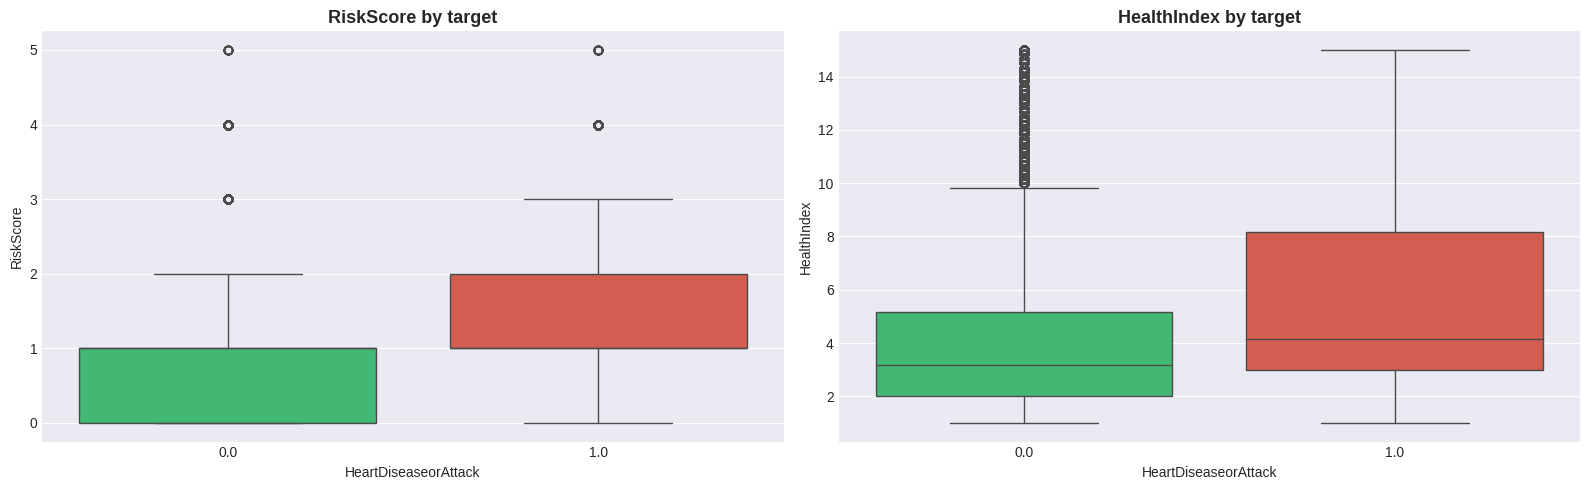

In [177]:
# Analyze derived features
if 'RiskScore' in df_pd.columns and 'HealthIndex' in df_pd.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.boxplot(data=df_pd, x=TARGET_COL, y='RiskScore', palette=['#2ecc71', '#e74c3c'], ax=axes[0])
    axes[0].set_title('RiskScore by target', fontsize=13, fontweight='bold')
    sns.boxplot(data=df_pd, x=TARGET_COL, y='HealthIndex', palette=['#2ecc71', '#e74c3c'], ax=axes[1])
    axes[1].set_title('HealthIndex by target', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/derived_features.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skip derived feature plots: missing RiskScore or HealthIndex.')

## 5. PCA (optional)

In [ ]:
# PCA sur les features ORIGINALES uniquement
# Les features derivees (RiskScore, HealthIndex) sont des combinaisons lineaires
# des features originales — les inclure dans la PCA gonfle artificiellement
# la variance expliquee par le premier composant.

DERIVED = ['RiskScore', 'HealthIndex']
original_feature_cols = [c for c in df_pd.columns if c != TARGET_COL and c not in DERIVED]

df_pca_src = df_pd[original_feature_cols + [TARGET_COL]].dropna()
if len(df_pca_src) > PCA_MAX_ROWS:
    df_pca_src = df_pca_src.sample(n=PCA_MAX_ROWS, random_state=42)

X_raw = df_pca_src[original_feature_cols].values
y = df_pca_src[TARGET_COL].values

# Supprimer les features a variance nulle/quasi-nulle avant StandardScaler
from sklearn.feature_selection import VarianceThreshold
vt = VarianceThreshold(threshold=1e-6)
X_valid = vt.fit_transform(X_raw)
kept_mask = vt.get_support()
kept_features = [f for f, k in zip(original_feature_cols, kept_mask) if k]
dropped = [f for f, k in zip(original_feature_cols, kept_mask) if not k]
if dropped:
    print(f"Features a variance nulle exclues de la PCA : {dropped}")

scaler = SklearnScaler()
X_scaled = scaler.fit_transform(X_valid)

n_comp = min(10, X_scaled.shape[1])
pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"PCA sur {len(kept_features)} features originales, {len(df_pca_src):,} lignes")
for k, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f"  PC{k}: {ev*100:.1f}%  (cumulatif: {cv*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(range(1, len(explained_var)+1), explained_var * 100, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquee (%)')
axes[0].set_title('Variance expliquee par composante', fontsize=13, fontweight='bold')

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var * 100, 'bo-', linewidth=2)
axes[1].axhline(y=95, color='r', linestyle='--', label='95% seuil')
axes[1].set_xlabel('Nombre de composantes')
axes[1].set_ylabel('Variance cumulative (%)')
axes[1].set_title('Variance cumulative', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# FIXED (N-03-A): report ">N" when 95% is not reached within n_comp components
_candidates = np.where(cumulative_var >= 0.95)[0]
if len(_candidates) > 0:
    n95 = int(_candidates[0]) + 1
    n95_label = str(n95)
else:
    n95 = n_comp          # cap for downstream use
    n95_label = f">{n_comp}"   # honest label for reporting
print(f"\nVariance cumulee a {n_comp} composantes : {cumulative_var[-1]*100:.1f}%")
print(f"Composantes pour 95% de variance : {n95_label}")

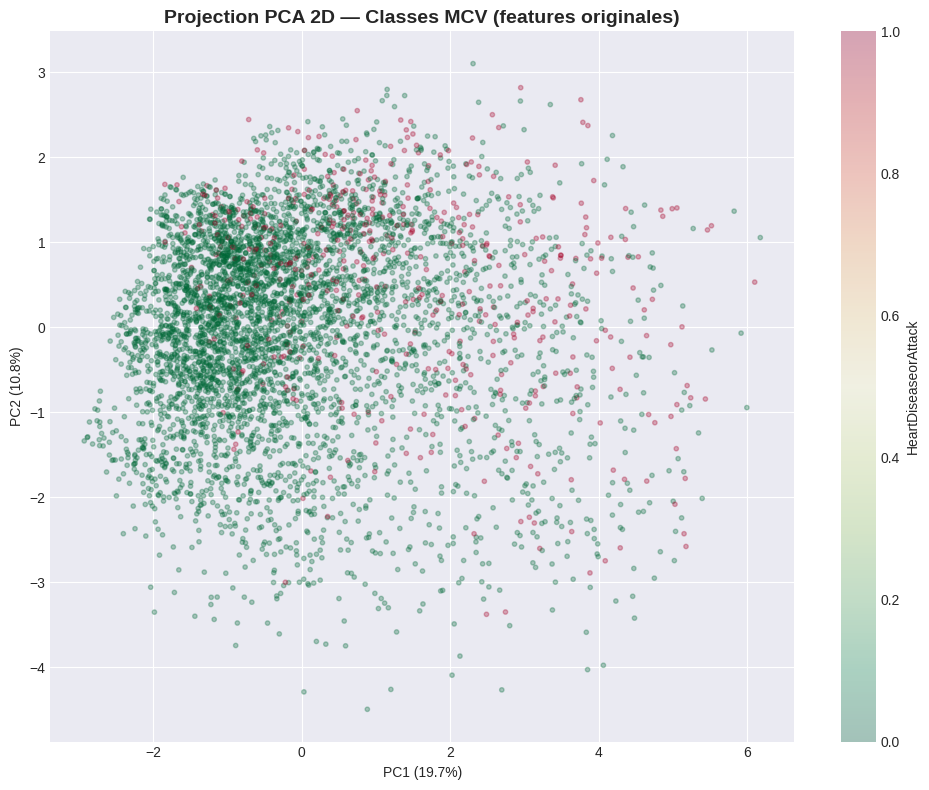

In [179]:
# Projection PCA 2D avec coloration par classe
n_plot = min(5000, len(X_pca))
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:n_plot, 0], X_pca[:n_plot, 1],
                      c=y[:n_plot], cmap='RdYlGn_r', alpha=0.3, s=10)
plt.colorbar(scatter, label=TARGET_COL)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
plt.title('Projection PCA 2D — Classes MCV (features originales)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Final feature selection

In [180]:
# Combine selection signals
corr_ranks = target_pearson.abs().rank(ascending=False)
gini_ranks = feature_importance_df.set_index('Feature')['Importance_Gini'].rank(ascending=False)

original_features = [c for c in df_spark.columns if c not in [TARGET_COL, 'RiskScore', 'HealthIndex']]
synthesis = pd.DataFrame(index=original_features)
synthesis['Corr_Pearson'] = target_pearson.abs().reindex(original_features)
synthesis['Corr_Rank'] = corr_ranks.reindex(original_features)
synthesis['Gini_Importance'] = feature_importance_df.set_index('Feature')['Importance_Gini'].reindex(original_features)
synthesis['Gini_Rank'] = gini_ranks.reindex(original_features)

if not chi2_df.empty:
    cramers_ranks = chi2_df.set_index('Variable')['Cramers_V'].rank(ascending=False)
    synthesis['Cramers_V'] = chi2_df.set_index('Variable')['Cramers_V'].reindex(original_features)
    synthesis['Cramers_Rank'] = cramers_ranks.reindex(original_features)
    rank_cols = ['Corr_Rank', 'Gini_Rank', 'Cramers_Rank']
else:
    rank_cols = ['Corr_Rank', 'Gini_Rank']

synthesis['Avg_Rank'] = synthesis[rank_cols].mean(axis=1)
synthesis = synthesis.sort_values('Avg_Rank')

print('Feature selection synthesis:')
print(synthesis.to_string())

FINAL_FEATURES = list(synthesis.index)
for extra in ['RiskScore', 'HealthIndex']:
    if extra in df_spark.columns:
        FINAL_FEATURES.append(extra)

print(f'Final features retained: {len(FINAL_FEATURES)}')
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f'  {i:2d}. {f}')

Feature selection synthesis:
                   Corr_Pearson  Corr_Rank  Gini_Importance  Gini_Rank  Cramers_V  Cramers_Rank   Avg_Rank
Age                    0.250119        1.0         0.340621        1.0   0.260560           1.0   1.000000
GenHlth                0.212742        2.0         0.203286        2.0   0.224875           2.0   2.000000
Stroke                 0.188268        3.0         0.161297        3.0   0.188230           3.0   3.000000
DiffWalk               0.182677        4.0         0.067008        5.0   0.182656           4.0   4.333333
Diabetes               0.164354        5.0         0.068093        4.0   0.164332           5.0   4.666667
PhysHlth               0.142649        6.0         0.032561        7.0        NaN           NaN   6.500000
Smoker                 0.096323        7.0         0.018752        8.0   0.096307           6.0   7.000000
Sex                    0.072215        9.0         0.057302        6.0   0.072198           8.0   7.666667
PhysActi

In [ ]:
# Sauvegarder les resultats du feature engineering

df_spark.write.mode('overwrite').parquet('/kaggle/working/brfss_featured.parquet')
print('Saved brfss_featured.parquet')

explained_list = explained_var.tolist() if 'explained_var' in globals() else []

feature_selection_results = {
    'final_features': FINAL_FEATURES,
    'n_features': len(FINAL_FEATURES),
    'derived_features': [f for f in ['RiskScore', 'HealthIndex'] if f in df_spark.columns],
    'riskscore_components': [c for c in ['HighBP', 'HighChol', 'Smoker', 'Diabetes', 'Stroke', 'DiffWalk', 'HvyAlcoholConsump'] if c in df_spark.columns],
    'riskscore_missing_from_prd': [c for c in ['HighBP', 'HighChol'] if c not in df_spark.columns],
    'feature_importance_gini': feature_importance_df.to_dict('records'),
    'chi2_results': chi2_df.to_dict('records'),
    # FIXED (N-03-A): use honest label ">10" when 95% not reached within n_comp components
    'pca_components_95pct': n95_label if 'n95_label' in globals() else None,
    'pca_explained_variance': explained_list,
    'pca_features_used': kept_features if 'kept_features' in globals() else []
}

with open('/kaggle/working/feature_selection_results.json', 'w') as f:
    json.dump(feature_selection_results, f, indent=2, default=str)

synthesis.to_csv('/kaggle/working/feature_synthesis.csv')
print('Saved feature_selection_results.json and feature_synthesis.csv')
print(f'\nSynthese:')
print(f'  Features originales : {len(FINAL_FEATURES) - len([f for f in FINAL_FEATURES if f in DERIVED])}')
print(f'  Features derivees   : {[f for f in FINAL_FEATURES if f in DERIVED]}')
print(f'  Total retenu        : {len(FINAL_FEATURES)}')

## Summary

- Pearson and Spearman correlations computed
- Gini importance from Random Forest
- Chi-square test and Cramers V for categorical features
- Derived features created: RiskScore and HealthIndex (if available)
- PCA analysis completed
- Final feature list synthesized and saved

Next: move to DNN training (notebook 04)